In [28]:
from pathlib import Path
import numpy as np
import rasterio
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Paths
cwd = Path.cwd()
if cwd.name == 'spi_gb_north':
    root = cwd
elif (cwd / 'spi_gb_north').exists():
    root = cwd / 'spi_gb_north'
elif (cwd / 'sds' / 'spi_gb_north').exists():
    root = cwd / 'sds' / 'spi_gb_north'
else:
    root = cwd

data_interim = root / 'data' / 'interim'
dem_path     = data_interim / 'dem_32643_100m.tif'
output_tpi   = data_interim / 'tpi_products'
output_tpi.mkdir(parents=True, exist_ok=True)

print(f"Root:   {root}")
print(f"DEM:    {dem_path}")
print(f"Output: {output_tpi}")
print("✓ Setup complete")

Root:   c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north
DEM:    c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\interim\dem_32643_100m.tif
Output: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\interim\tpi_products
✓ Setup complete


In [29]:
print("Loading DEM...")

with rasterio.open(dem_path) as src:
    dem_data      = src.read(1).astype(np.float32)
    dem_crs       = src.crs
    dem_transform = src.transform
    dem_nodata    = src.nodata
    dem_res       = src.res
    dem_meta      = src.meta.copy()

# Build nodata mask — name it tpi_nodata_mask to avoid collisions
tpi_nodata_mask = np.isnan(dem_data)
if dem_nodata is not None and not np.isnan(dem_nodata):
    tpi_nodata_mask |= (dem_data == dem_nodata)

n_valid = (~tpi_nodata_mask).sum()
pixel_size = abs(dem_res[0])

print(f"  CRS:        {dem_crs}")
print(f"  Shape:      {dem_data.shape}")
print(f"  Resolution: {pixel_size:.0f}m")
print(f"  Valid px:   {n_valid:,} / {dem_data.size:,} ({100*n_valid/dem_data.size:.1f}%)")
print(f"  Elevation:  [{np.nanmin(dem_data):.1f}, {np.nanmax(dem_data):.1f}] m")
print(f"  Mean elev:  {np.nanmean(dem_data):.1f} m")

Loading DEM...
  CRS:        EPSG:32643
  Shape:      (4801, 6122)
  Resolution: 100m
  Valid px:   12,619,101 / 29,391,722 (42.9%)
  Elevation:  [225.5, 8533.2] m
  Mean elev:  3547.2 m


In [30]:
# ============================================================================
# TPI COMPUTATION
# ============================================================================
# TPI = pixel elevation − mean elevation of surrounding neighborhood
# Neighborhood radius = 2 pixels → 5×5 window → ~400m real-world scale
# Center pixel is EXCLUDED from neighborhood mean (Weiss 2001).
#
# Quality filter: pixels with < 50% valid neighbors (< 12 of 24 surrounding
# pixels) are masked as nodata — their neighborhood means are statistically
# unreliable (AOI boundary pixels, nodata-adjacent pixels).
#
# Outlier clip: 55 pixels in the Karakoram/Hindukush AOI exceed ±500m TPI.
# These are real geomorphic discontinuities (cirque walls, serac zones,
# hanging valley lips) at high elevation (mean 5000–7100m), not artifacts —
# all have ≥12 valid neighbors. However, they are statistical outliers
# (beyond P99.9) that inflate std and compress z-scores for all other pixels.
# Clipping at ±300m before z-scoring is physically motivated: 300m relief
# within a ~400m window implies a mean slope of ~56°, above any sustained
# terrain surface. The clip affects <0.001% of the AOI.
# ============================================================================

RADIUS              = 2     # pixels
MIN_VALID_NEIGHBORS = 12    # 50% of 24 surrounding pixels
TPI_CLIP_M          = 300.0 # meters — outlier clip before z-scoring

window_size = 2 * RADIUS + 1
n_pixels    = window_size ** 2   # 25 total (including center)
n_neighbors = n_pixels - 1       # 24 surrounding pixels

print("TPI Parameters:")
print(f"  Radius:               {RADIUS} pixels")
print(f"  Window:               {window_size}×{window_size} ({n_pixels} total pixels)")
print(f"  Surrounding pixels:   {n_neighbors}")
print(f"  Real scale:           ~{RADIUS * pixel_size * 2:.0f}m")
print(f"  Min valid neighbors:  {MIN_VALID_NEIGHBORS} of {n_neighbors} ({100*MIN_VALID_NEIGHBORS/n_neighbors:.0f}%)")
print(f"  Outlier clip:         ±{TPI_CLIP_M:.0f}m")

# ---- Step 1: Build inputs for focal mean ----
print("\nStep 1: Computing neighborhood mean (center pixel excluded)...")

# Replace nodata with 0 for windowed summation
# Valid pixel indicator tracks where real data exists
dem_filled  = np.where(tpi_nodata_mask, 0.0, dem_data.astype(np.float32))
valid_float = np.where(tpi_nodata_mask, 0.0, 1.0).astype(np.float32)

# uniform_filter computes the mean over the window
# Multiply by n_pixels to recover the sum
window_sum   = uniform_filter(dem_filled,  size=window_size, mode='nearest') * n_pixels
window_count = uniform_filter(valid_float, size=window_size, mode='nearest') * n_pixels

# ---- Step 2: Exclude center pixel from neighborhood ----
# Subtract the center pixel's own elevation and validity from window totals
# so we compare each pixel to its surroundings only, not to itself
center_elev  = np.where(tpi_nodata_mask, 0.0, dem_data.astype(np.float32))
center_valid = (~tpi_nodata_mask).astype(np.float32)

neighborhood_sum   = window_sum   - center_elev
neighborhood_count = window_count - center_valid

print(f"  Neighborhood count range: [{np.nanmin(neighborhood_count):.0f}, {np.nanmax(neighborhood_count):.0f}]")
print(f"  (max should be {n_neighbors} for fully interior pixels)")

# ---- Step 3: Quality filter — minimum neighbor threshold ----
# Pixels with too few valid neighbors have unreliable neighborhood means.
# These are almost entirely AOI boundary pixels and nodata-adjacent pixels.
# Masking them is methodologically principled — not cosmetic clipping.
sparse_mask = (neighborhood_count < MIN_VALID_NEIGHBORS) & ~tpi_nodata_mask

print(f"\nStep 2: Applying minimum neighbor threshold (>= {MIN_VALID_NEIGHBORS})...")
print(f"  Sparse pixels removed: {sparse_mask.sum():,} ({100*sparse_mask.sum()/n_valid:.2f}% of AOI)")
print(f"  These are boundary/nodata-adjacent pixels with unstable means")

# Update nodata mask to include sparse pixels
tpi_nodata_mask_final = tpi_nodata_mask | sparse_mask

# ---- Step 4: Compute neighborhood mean (safe division) ----
# Set count to NaN where below threshold to propagate nodata cleanly
safe_count = np.where(
    tpi_nodata_mask_final | (neighborhood_count < 1),
    np.nan,
    neighborhood_count
)
neighborhood_mean = neighborhood_sum / safe_count

# ---- Step 5: TPI = elevation − neighborhood mean ----
print(f"\nStep 3: Computing raw TPI = elevation − neighborhood mean...")

tpi_raw = dem_data.astype(np.float32) - neighborhood_mean
tpi_raw[tpi_nodata_mask_final] = np.nan

print(f"  Raw TPI range:  [{np.nanmin(tpi_raw):.2f}, {np.nanmax(tpi_raw):.2f}] m")
print(f"  Raw TPI mean:   {np.nanmean(tpi_raw):.4f} m  (should be ≈ 0)")
print(f"  Raw TPI std:    {np.nanstd(tpi_raw):.2f} m")

mean_abs = abs(np.nanmean(tpi_raw))
if mean_abs < 1.0:
    print(f"  ✓ Mean ≈ 0 confirmed ({mean_abs:.4f}m) — formula correct")
else:
    print(f"  ⚠️ Mean = {mean_abs:.2f}m — check focal mean computation")

# ---- Step 6: Outlier clip ----
# Clip before z-scoring so that <0.001% of extreme pixels (genuine Karakoram
# geomorphic discontinuities) do not inflate std and compress z-scores for
# the remaining 12M+ pixels. See header comment for physical justification.
print(f"\nStep 4: Clipping raw TPI to ±{TPI_CLIP_M:.0f}m before z-scoring...")

valid_mask  = ~tpi_nodata_mask_final & np.isfinite(tpi_raw)
n_clipped   = int(np.sum(np.abs(tpi_raw[valid_mask]) > TPI_CLIP_M))

tpi_clipped = np.clip(tpi_raw, -TPI_CLIP_M, TPI_CLIP_M)
tpi_clipped[~valid_mask] = np.nan

print(f"  Pixels clipped: {n_clipped:,} ({100*n_clipped/valid_mask.sum():.4f}% of AOI)")
print(f"  Clipped TPI range: [{np.nanmin(tpi_clipped):.2f}, {np.nanmax(tpi_clipped):.2f}] m")

# ---- Step 7: Z-score normalisation ----
print(f"\nStep 5: Z-score normalisation (on clipped TPI)...")

tpi_mean = float(np.nanmean(tpi_clipped[valid_mask]))
tpi_std  = float(np.nanstd(tpi_clipped[valid_mask]))

print(f"  Mean: {tpi_mean:.4f} m")
print(f"  Std:  {tpi_std:.4f} m")

tpi_zscore = (tpi_clipped - tpi_mean) / tpi_std
tpi_zscore[~valid_mask] = np.nan

print(f"  Z-score range: [{np.nanmin(tpi_zscore):.3f}, {np.nanmax(tpi_zscore):.3f}]")
print(f"  Z-score mean:  {np.nanmean(tpi_zscore):.6f}  (should be ≈ 0)")
print(f"  Z-score std:   {np.nanstd(tpi_zscore):.6f}  (should be ≈ 1)")

# ---- Expose outputs for downstream cells ----
tpi_nodata_mask = tpi_nodata_mask_final
n_valid_final   = int(valid_mask.sum())
print(f"\n  Valid pixels after filtering: {n_valid_final:,} ({100*n_valid_final/dem_data.size:.1f}% of bounding box)")

TPI Parameters:
  Radius:               2 pixels
  Window:               5×5 (25 total pixels)
  Surrounding pixels:   24
  Real scale:           ~400m
  Min valid neighbors:  12 of 24 (50%)
  Outlier clip:         ±300m

Step 1: Computing neighborhood mean (center pixel excluded)...
  Neighborhood count range: [0, 24]
  (max should be 24 for fully interior pixels)

Step 2: Applying minimum neighbor threshold (>= 12)...
  Sparse pixels removed: 439 (0.00% of AOI)
  These are boundary/nodata-adjacent pixels with unstable means

Step 3: Computing raw TPI = elevation − neighborhood mean...
  Raw TPI range:  [-1224.25, 1451.77] m
  Raw TPI mean:   -0.0012 m  (should be ≈ 0)
  Raw TPI std:    27.99 m
  ✓ Mean ≈ 0 confirmed (0.0012m) — formula correct

Step 4: Clipping raw TPI to ±300m before z-scoring...
  Pixels clipped: 189 (0.0015% of AOI)
  Clipped TPI range: [-300.00, 300.00] m

Step 5: Z-score normalisation (on clipped TPI)...
  Mean: -0.0002 m
  Std:  27.9501 m
  Z-score range: [-10.

In [31]:
# ============================================================================
# LANDFORM CLASSIFICATION
# ============================================================================
# tpi_zscore is produced in the TPI cell (clipped at ±300m before z-scoring).
# Do NOT recompute here — classify directly from it.
# Thresholds follow Weiss (2001): ±1 z-score separates ridges from valleys.
# Expected under normality: ~16% ridges, ~68% mid-slope, ~16% valleys.
# Deviations are expected — northern Pakistan has asymmetric relief.
# ============================================================================

print("Classifying landforms...")
print(f"  Using tpi_zscore from TPI cell (clipped at ±{TPI_CLIP_M:.0f}m before z-scoring)")
print(f"  Z-score range: [{np.nanmin(tpi_zscore):.3f}, {np.nanmax(tpi_zscore):.3f}]")
print(f"  Z-score mean:  {np.nanmean(tpi_zscore):.6f}  (should be ≈ 0)")
print(f"  Z-score std:   {np.nanstd(tpi_zscore):.6f}  (should be ≈ 1)")

RIDGE_THRESH  =  1.0
VALLEY_THRESH = -1.0

tpi_class = np.full(tpi_zscore.shape, 3, dtype=np.int32)  # 3 = nodata
tpi_class[tpi_zscore >  RIDGE_THRESH]                                    = 0  # ridge
tpi_class[(tpi_zscore >= VALLEY_THRESH) & (tpi_zscore <= RIDGE_THRESH)]  = 1  # mid-slope
tpi_class[tpi_zscore <  VALLEY_THRESH]                                   = 2  # valley

print(f"\n  Landform distribution:")
print(f"    Ridge     (z > +{RIDGE_THRESH}):          {(tpi_class==0).sum():>10,}  ({100*(tpi_class==0).sum()/n_valid_final:.1f}% of AOI)")
print(f"    Mid-slope ({VALLEY_THRESH} to +{RIDGE_THRESH}):  {(tpi_class==1).sum():>10,}  ({100*(tpi_class==1).sum()/n_valid_final:.1f}% of AOI)")
print(f"    Valley    (z < {VALLEY_THRESH}):          {(tpi_class==2).sum():>10,}  ({100*(tpi_class==2).sum()/n_valid_final:.1f}% of AOI)")

Classifying landforms...
  Using tpi_zscore from TPI cell (clipped at ±300m before z-scoring)
  Z-score range: [-10.733, 10.733]
  Z-score mean:  -0.000000  (should be ≈ 0)
  Z-score std:   1.000000  (should be ≈ 1)

  Landform distribution:
    Ridge     (z > +1.0):           1,840,103  (14.6% of AOI)
    Mid-slope (-1.0 to +1.0):   9,145,827  (72.5% of AOI)
    Valley    (z < -1.0):           1,632,732  (12.9% of AOI)


In [32]:
# ============================================================================
# SAVE TPI OUTPUTS
# ============================================================================
# Three files are written:
#   1. tpi_raw        — raw TPI in metres (unclipped); input to SPI
#   2. tpi_zscore     — z-scored TPI (clipped at ±300m before z-scoring)
#   3. tpi_landforms  — integer class raster (0=ridge 1=mid 2=valley 3=nodata)
# ============================================================================

print("Saving TPI outputs...")

base_meta = {
    'driver':    'GTiff',
    'crs':       dem_crs,
    'transform': dem_transform,
    'width':     dem_data.shape[1],
    'height':    dem_data.shape[0],
    'count':     1,
    'compress':  'lzw',
    'nodata':    np.nan,
}

# 1. Raw TPI (metres) — unclipped, used by SPI
raw_path = output_tpi / f"tpi_raw_radius{RADIUS}_32643_100m.tif"
with rasterio.open(raw_path, 'w', **{**base_meta, 'dtype': 'float32'}) as dst:
    dst.write(tpi_raw.astype(np.float32), 1)
print(f"  ✓ Raw TPI saved:     {raw_path.name}")

# 2. Z-scored TPI — clipped at ±300m before z-scoring (see TPI cell)
zscore_path = output_tpi / f"tpi_zscore_radius{RADIUS}_32643_100m.tif"
with rasterio.open(zscore_path, 'w', **{**base_meta, 'dtype': 'float32'}) as dst:
    dst.write(tpi_zscore.astype(np.float32), 1)
print(f"  ✓ Z-score TPI saved: {zscore_path.name}")

# 3. Landform classification — nodata value is 3 (not NaN — integer raster)
class_path = output_tpi / f"tpi_landforms_radius{RADIUS}_32643_100m.tif"
with rasterio.open(class_path, 'w', **{**base_meta, 'dtype': 'int32', 'nodata': 3}) as dst:
    dst.write(tpi_class.astype(np.int32), 1)
print(f"  ✓ Landforms saved:   {class_path.name}")

# ---- Final sanity checks ----
print(f"\nSanity checks:")
print(f"  Raw TPI mean ≈ 0:  {abs(np.nanmean(tpi_raw)) < 1.0}  ({np.nanmean(tpi_raw):.4f}m)")
print(f"  Z-score mean ≈ 0:  {abs(np.nanmean(tpi_zscore)) < 0.01}  ({np.nanmean(tpi_zscore):.6f})")
print(f"  Z-score std  ≈ 1:  {abs(np.nanstd(tpi_zscore[valid_mask]) - 1.0) < 0.01}  ({np.nanstd(tpi_zscore[valid_mask]):.6f})")
print(f"\n{'='*50}")
print(f"TPI COMPLETE")
print(f"  Files written to: {output_tpi}")
print(f"{'='*50}")

Saving TPI outputs...
  ✓ Raw TPI saved:     tpi_raw_radius2_32643_100m.tif
  ✓ Z-score TPI saved: tpi_zscore_radius2_32643_100m.tif
  ✓ Landforms saved:   tpi_landforms_radius2_32643_100m.tif

Sanity checks:
  Raw TPI mean ≈ 0:  True  (-0.0012m)
  Z-score mean ≈ 0:  True  (-0.000000)
  Z-score std  ≈ 1:  True  (1.000000)

TPI COMPLETE
  Files written to: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\interim\tpi_products


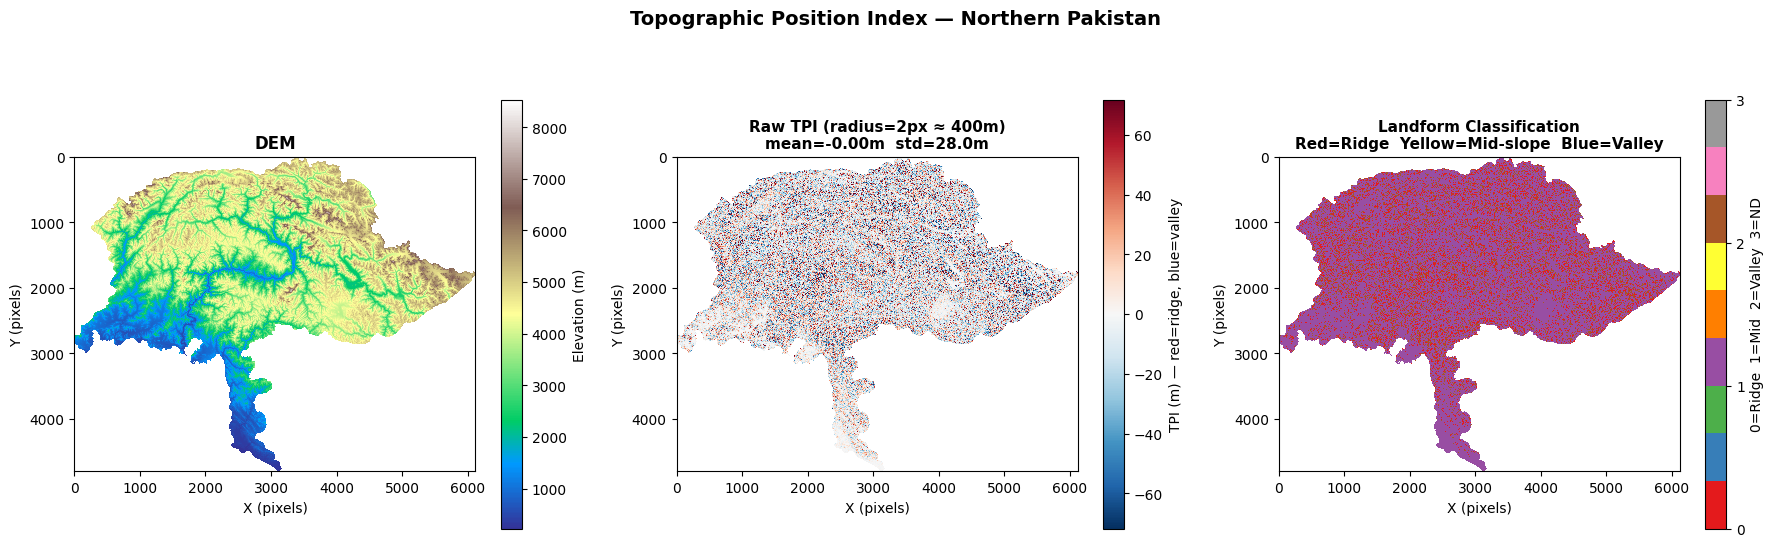

✓ Visualization saved: tpi_visualization.png


In [33]:
# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')

cmap_dem   = plt.cm.terrain.copy(); cmap_dem.set_bad('white')
cmap_tpi   = plt.cm.RdBu_r.copy(); cmap_tpi.set_bad('white')
cmap_class = plt.cm.Set1.copy();    cmap_class.set_bad('white')

# Panel 1 — DEM
im0 = axes[0].imshow(
    np.where(tpi_nodata_mask, np.nan, dem_data),
    cmap=cmap_dem, interpolation='nearest'
)
axes[0].set_title('DEM', fontsize=12, fontweight='bold')
plt.colorbar(im0, ax=axes[0], shrink=0.8, label='Elevation (m)')

# Panel 2 — Raw TPI (symmetric colorbar at 98th percentile, unclipped)
tpi_abs_max = np.nanpercentile(np.abs(tpi_raw[~tpi_nodata_mask]), 98)
im1 = axes[1].imshow(
    tpi_raw, cmap=cmap_tpi,
    vmin=-tpi_abs_max, vmax=tpi_abs_max,
    interpolation='nearest'
)
axes[1].set_title(
    f'Raw TPI (radius={RADIUS}px ≈ {RADIUS*pixel_size*2:.0f}m)\n'
    f'mean={np.nanmean(tpi_raw):.2f}m  std={np.nanstd(tpi_raw):.1f}m',
    fontsize=11, fontweight='bold'
)
plt.colorbar(im1, ax=axes[1], shrink=0.8, label='TPI (m) — red=ridge, blue=valley')

# Panel 3 — Landform classification
class_display = np.where(tpi_nodata_mask, np.nan, tpi_class.astype(np.float32))
im2 = axes[2].imshow(
    class_display, cmap=cmap_class,
    vmin=0, vmax=3, interpolation='nearest'
)
axes[2].set_title(
    'Landform Classification\n'
    'Red=Ridge  Yellow=Mid-slope  Blue=Valley',
    fontsize=11, fontweight='bold'
)
plt.colorbar(im2, ax=axes[2], shrink=0.8,
             ticks=[0, 1, 2, 3], label='0=Ridge  1=Mid  2=Valley  3=ND')

for ax in axes:
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')

plt.suptitle('Topographic Position Index — Northern Pakistan',
             fontsize=14, fontweight='bold')
plt.tight_layout()

viz_path = output_tpi / 'tpi_visualization.png'
plt.savefig(viz_path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Visualization saved: {viz_path.name}")

In [34]:
# Run this as a diagnostic cell to understand where the extremes are coming from

print("Diagnosing extreme TPI values...")

# Find the most extreme pixels
extreme_high = tpi_raw > 500   # well above normal ridge
extreme_low  = tpi_raw < -500  # well below normal valley

print(f"\nPixels with TPI > 500m:  {extreme_high.sum():,}")
print(f"Pixels with TPI < -500m: {extreme_low.sum():,}")

# Check how many valid neighbors these extreme pixels have
extreme_mask = extreme_high | extreme_low
if extreme_mask.sum() > 0:
    neighbor_counts_at_extremes = neighborhood_count[extreme_mask]
    print(f"\nNeighbor counts at extreme pixels:")
    print(f"  Min:    {neighbor_counts_at_extremes.min():.0f}")
    print(f"  Max:    {neighbor_counts_at_extremes.max():.0f}")
    print(f"  Mean:   {neighbor_counts_at_extremes.mean():.1f}")
    print(f"  Pixels with full 24 neighbors: {(neighbor_counts_at_extremes == 24).sum():,}")

# Check elevation at extreme TPI pixels
print(f"\nElevation at TPI > 500m pixels:")
if extreme_high.sum() > 0:
    print(f"  Elevation range: [{dem_data[extreme_high].min():.0f}, {dem_data[extreme_high].max():.0f}] m")
    print(f"  Mean elevation:  {dem_data[extreme_high].mean():.0f} m")

print(f"\nElevation at TPI < -500m pixels:")
if extreme_low.sum() > 0:
    print(f"  Elevation range: [{dem_data[extreme_low].min():.0f}, {dem_data[extreme_low].max():.0f}] m")
    print(f"  Mean elevation:  {dem_data[extreme_low].mean():.0f} m")

# Distribution of ALL TPI values
percentiles = [1, 5, 25, 50, 75, 95, 99]
valid_tpi = tpi_raw[~tpi_nodata_mask & np.isfinite(tpi_raw)]
print(f"\nTPI percentile breakdown:")
for p in percentiles:
    print(f"  P{p:02d}: {np.nanpercentile(valid_tpi, p):>8.2f} m")
print(f"  Min: {valid_tpi.min():>8.2f} m")
print(f"  Max: {valid_tpi.max():>8.2f} m")

Diagnosing extreme TPI values...

Pixels with TPI > 500m:  13
Pixels with TPI < -500m: 42

Neighbor counts at extreme pixels:
  Min:    12
  Max:    24
  Mean:   22.1
  Pixels with full 24 neighbors: 39

Elevation at TPI > 500m pixels:
  Elevation range: [6179, 7791] m
  Mean elevation:  7114 m

Elevation at TPI < -500m pixels:
  Elevation range: [3498, 6393] m
  Mean elevation:  5088 m

TPI percentile breakdown:
  P01:   -61.51 m
  P05:   -41.47 m
  P25:   -17.00 m
  P50:    -2.29 m
  P75:    14.11 m
  P95:    51.26 m
  P99:    79.44 m
  Min: -1224.25 m
  Max:  1451.77 m
